# DBSCAN Clustering Implementation

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns

warnings.filterwarnings('ignore')

In [110]:
from sklearn.datasets import make_moons,make_circles

X,y=make_moons(n_samples=500,noise=0.10,random_state=42)
# X

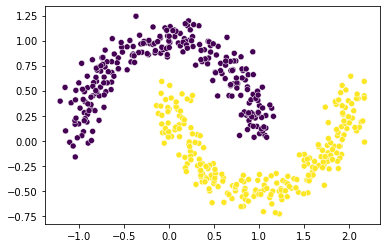

In [111]:
sns.scatterplot(X[:,0],X[:,1],c=y);

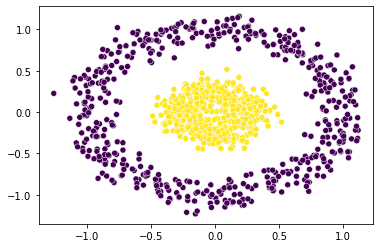

In [112]:
X_circle,y_circle=make_circles(n_samples=1000,random_state=42,noise=0.10,factor=0.25)
sns.scatterplot(X_circle[:,0],X_circle[:,1],c=y_circle);

In [113]:
from sklearn.preprocessing import StandardScaler


sc=StandardScaler()

X_scaled=sc.fit_transform(X)
X_circle_scaled=sc.fit_transform(X_circle)

Silhouette Score: 0.22547091556371043


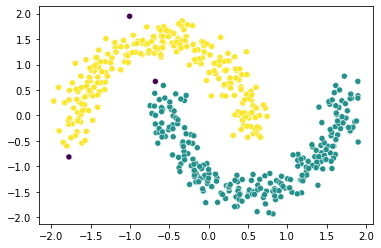

In [114]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan=DBSCAN(eps=0.3,min_samples=11)
dbscan.fit(X_scaled)
labels=dbscan.labels_
sns.scatterplot(X_scaled[:,0],X_scaled[:,1],c=labels);
print(f'Silhouette Score: {silhouette_score(X_scaled,labels)}')

Silhouette Score: 0.2081303679907239


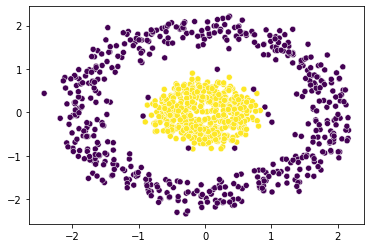

In [115]:
dbscan_circle=DBSCAN(eps=0.2,min_samples=16)
dbscan_circle.fit(X_circle_scaled)
labels_circle=dbscan_circle.labels_
sns.scatterplot(X_circle_scaled[:,0],X_circle_scaled[:,1],c=labels_circle);
print(f'Silhouette Score: {silhouette_score(X_circle_scaled,labels_circle)}')

<b>Silhouette Score</b> favors compact, well-separated clusters. <b>DBSCAN</b> is designed to discover arbitrarily shaped clusters (such as moons or circles).

In these shapes, points within the same cluster can be far apart, increasing the average intra-cluster distance (a). As a result, the Silhouette Score may be low even though the clustering is correct.

Other Metrics: <b>Davies-Bouldin</b>, <b>Calinski-Harabasz</b>

In [117]:
from sklearn.metrics import davies_bouldin_score,calinski_harabasz_score

db_score = davies_bouldin_score(X, labels)
ch_score = calinski_harabasz_score(X, labels)


db_circle_score=davies_bouldin_score(X_circle,labels_circle)
ch_circle_score=calinski_harabasz_score(X_circle,labels_circle)


print(f'Moon Dataset:\nDavies Bouldin Score: {db_score}\nCalinski Harabasz Score: {ch_score}\n\n')
print(f'Circle Dataset:\nDavies Bouldin Score: {db_circle_score}\nCalinski Harabasz Score: {ch_circle_score}')


Moon Dataset:
Davies Bouldin Score: 2.193996349021193
Calinski Harabasz Score: 166.98730429878663


Circle Dataset:
Davies Bouldin Score: 160.7301668466675
Calinski Harabasz Score: 0.028044815852856647
